In [4]:
import seaborn as sns
import pandas as pd


path = "../data/evaluate_results/evaluation_results.csv"
df = pd.read_csv(path)
df.head()

,timestamp,experiment_id,agg_mode,alpha,chunk_size,collection_name,cosine_threshold,coverage@5,coverage@5_semantic,embedding_model,...,precision@5_semantic,qdrant_path,recall@5,recall@5_semantic,retrieval_mode,retrieve_k,rrf_k,search_type,strategy,top_k
0,20251109_125417,exp_20251109_125417,max,0.5,380,chunks_recursive_380_50_qwen_qwen3_embedding_0_6b,0.7,0.68,0.670,Qwen/Qwen3-Embedding-0.6B,...,0.783,langchain_qdrant,0.566667,0.559167,dense,20,60,similarity,recursive,5
1,20251109_130131,exp_20251109_130131,max,0.7,380,chunks_recursive_380_50_qwen_qwen3_embedding_0_6b,0.7,0.68,0.670,Qwen/Qwen3-Embedding-0.6B,...,0.783,langchain_qdrant,0.566667,0.559167,hybrid,20,60,hybrid_rrf,recursive,5
2,20251109_133308,exp_20251109_133308,max,0.5,380,chunks_recursive_380_50_baai_bge_m3,0.7,0.58,0.555,BAAI/bge-m3,...,0.632,langchain_qdrant,0.489167,0.469167,dense,20,60,similarity,recursive,5
3,20251109_133956,exp_20251109_133956,max,0.7,380,chunks_recursive_380_50_baai_bge_m3,0.7,0.58,0.555,BAAI/bge-m3,...,0.632,langchain_qdrant,0.489167,0.469167,hybrid,20,60,hybrid_rrf,recursive,5


In [5]:
# Cell 2: Prepare data
import matplotlib.pyplot as plt

# Tạo cột model_name ngắn gọn
df['model_short'] = df['embedding_model'].apply(lambda x: x.split('/')[-1])

# Tạo label kết hợp model + retrieval mode
df['config'] = df['model_short'] + '\n(' + df['retrieval_mode'] + ')'

print(f"Total experiments: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nModels: {df['model_short'].unique()}")
print(f"Retrieval modes: {df['retrieval_mode'].unique()}")

Total experiments: 4

Columns: ['timestamp', 'experiment_id', 'agg_mode', 'alpha', 'chunk_size', 'collection_name', 'cosine_threshold', 'coverage@5', 'coverage@5_semantic', 'embedding_model', 'eval_method', 'hit_rate@5', 'hit_rate@5_semantic', 'max_queries', 'mode', 'mrr@5', 'mrr@5_semantic', 'ndcg@5', 'ndcg@5_semantic', 'num_queries', 'overlap', 'precision@5', 'precision@5_semantic', 'qdrant_path', 'recall@5', 'recall@5_semantic', 'retrieval_mode', 'retrieve_k', 'rrf_k', 'search_type', 'strategy', 'top_k', 'model_short', 'config']

Models: ['Qwen3-Embedding-0.6B' 'bge-m3']
Retrieval modes: ['dense' 'hybrid']


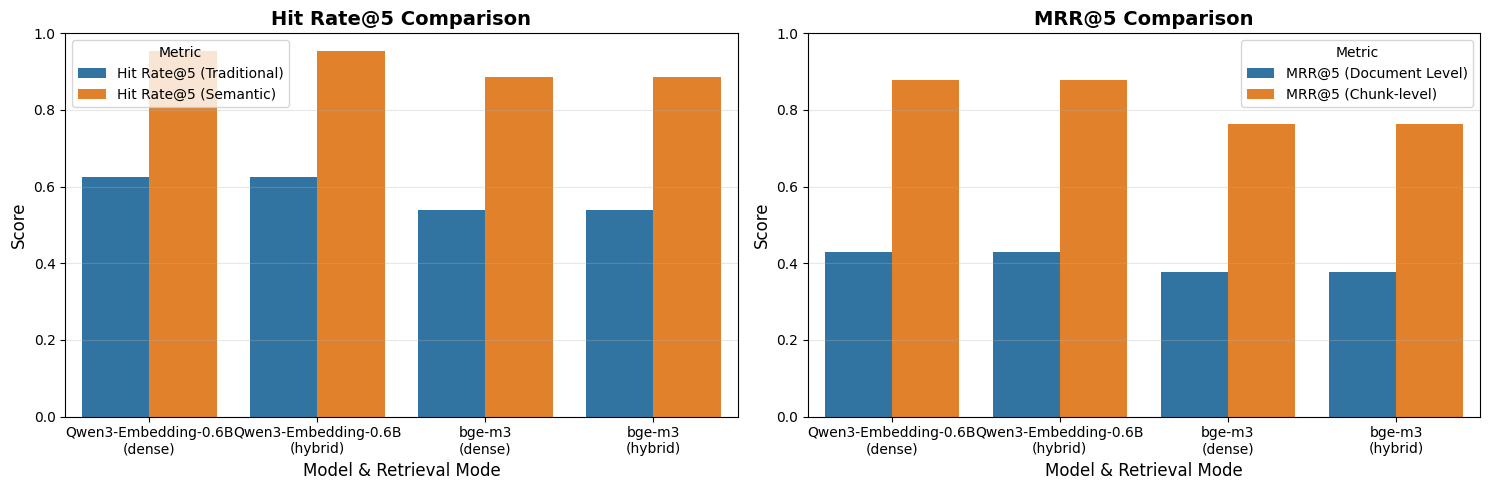

In [ ]:
# Cell 3: Plot Hit Rate & MRR
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hit Rate
df_plot = df[['config', 'hit_rate@5', 'hit_rate@5_semantic']].copy()
df_plot = df_plot.melt(id_vars='config', var_name='metric', value_name='score')
df_plot['metric_label'] = df_plot['metric'].map({
    'hit_rate@5': 'Hit Rate@5 (Traditional)',
    'hit_rate@5_semantic': 'Hit Rate@5 (ChunkChunkSemantic)'
})

sns.barplot(data=df_plot, x='config', y='score', hue='metric_label', ax=axes[0])
axes[0].set_title('Hit Rate@5 Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Model & Retrieval Mode', fontsize=12)
axes[0].legend(title='Metric')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# MRR
df_plot = df[['config', 'mrr@5', 'mrr@5_semantic']].copy()
df_plot = df_plot.melt(id_vars='config', var_name='metric', value_name='score')
df_plot['metric_label'] = df_plot['metric'].map({
    'mrr@5': 'MRR@5 (Document Level)',
    'mrr@5_semantic': 'MRR@5 (Chunk-level)'
})

sns.barplot(data=df_plot, x='config', y='score', hue='metric_label', ax=axes[1])
axes[1].set_title('MRR@5 Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_xlabel('Model & Retrieval Mode', fontsize=12)
axes[1].legend(title='Metric')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

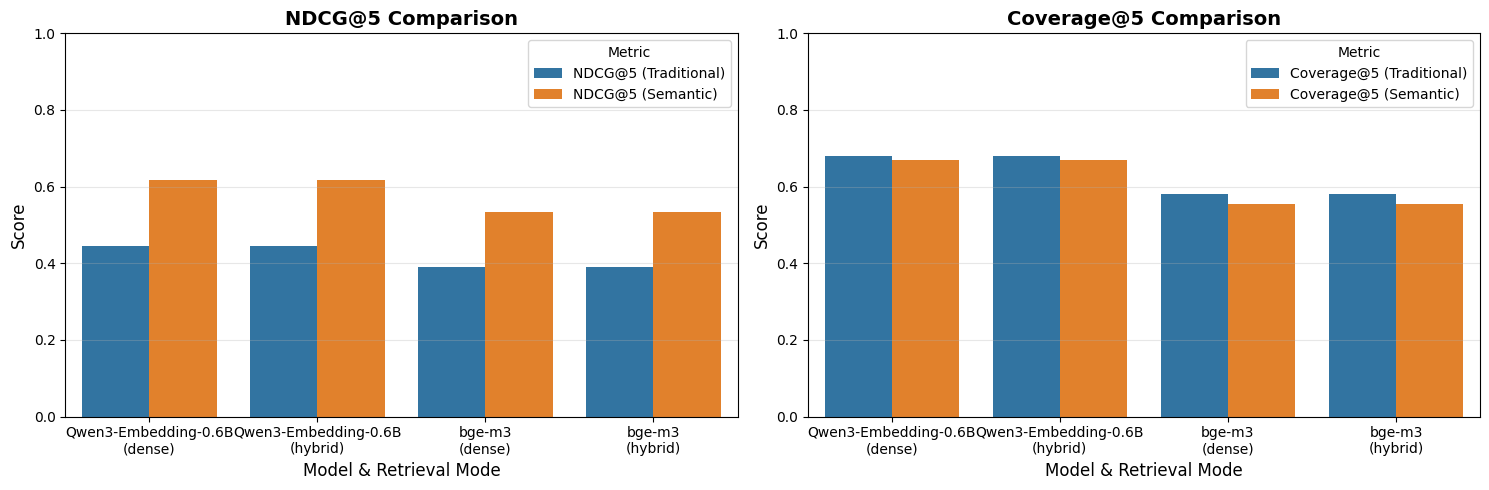

In [ ]:
# Cell 4: Plot NDCG & Coverage
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# NDCG
df_plot = df[['config', 'ndcg@5', 'ndcg@5_semantic']].copy()
df_plot = df_plot.melt(id_vars='config', var_name='metric', value_name='score')
df_plot['metric_label'] = df_plot['metric'].map({
    'ndcg@5': 'NDCG@5 (Traditional)',
    'ndcg@5_semantic': 'NDCG@5 (ChunkSemantic)'
})

sns.barplot(data=df_plot, x='config', y='score', hue='metric_label', ax=axes[0])
axes[0].set_title('NDCG@5 Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Model & Retrieval Mode', fontsize=12)
axes[0].legend(title='Metric')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Coverage
df_plot = df[['config', 'coverage@5', 'coverage@5_semantic']].copy()
df_plot = df_plot.melt(id_vars='config', var_name='metric', value_name='score')
df_plot['metric_label'] = df_plot['metric'].map({
    'coverage@5': 'Coverage@5 (Traditional)',
    'coverage@5_semantic': 'Coverage@5 (ChunkSemantic)'
})

sns.barplot(data=df_plot, x='config', y='score', hue='metric_label', ax=axes[1])
axes[1].set_title('Coverage@5 Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_xlabel('Model & Retrieval Mode', fontsize=12)
axes[1].legend(title='Metric')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Cell 7: Summary table
summary = df[['embedding_model', 'retrieval_mode', 'hit_rate@5', 'hit_rate@5_semantic', 
              'mrr@5', 'mrr@5_semantic', 'ndcg@5', 'ndcg@5_semantic']].copy()

summary.columns = ['Model', 'Mode', 'Hit@5', 'Hit@5_ChunkSem', 'MRR@5', 'MRR@5_ChunkSem', 'NDCG@5', 'NDCG@5_ChunkSem']

# Style the table
summary_styled = summary.style.format({
    'Hit@5': '{:.3f}',
    'Hit@5_ChunkSem': '{:.3f}',
    'MRR@5': '{:.3f}',
    'MRR@5_ChunkSem': '{:.3f}',
    'NDCG@5': '{:.3f}',
    'NDCG@5_ChunkSem': '{:.3f}'
}).background_gradient(subset=['Hit@5', 'Hit@5_ChunkSem', 'MRR@5', 'MRR@5_ChunkSem', 'NDCG@5', 'NDCG@5_ChunkSem'], 
                      cmap='RdYlGn')

summary_styled

,Model,Mode,Hit@5,Hit@5_ChunkSem,MRR@5,MRR@5_ChunkSem,NDCG@5,NDCG@5_ChunkSem
0,Qwen/Qwen3-Embedding-0.6B,dense,0.625,0.955,0.430,0.879,0.446,0.617
1,Qwen/Qwen3-Embedding-0.6B,hybrid,0.625,0.955,0.430,0.879,0.446,0.617
2,BAAI/bge-m3,dense,0.540,0.885,0.378,0.763,0.391,0.534
3,BAAI/bge-m3,hybrid,0.540,0.885,0.378,0.763,0.391,0.534


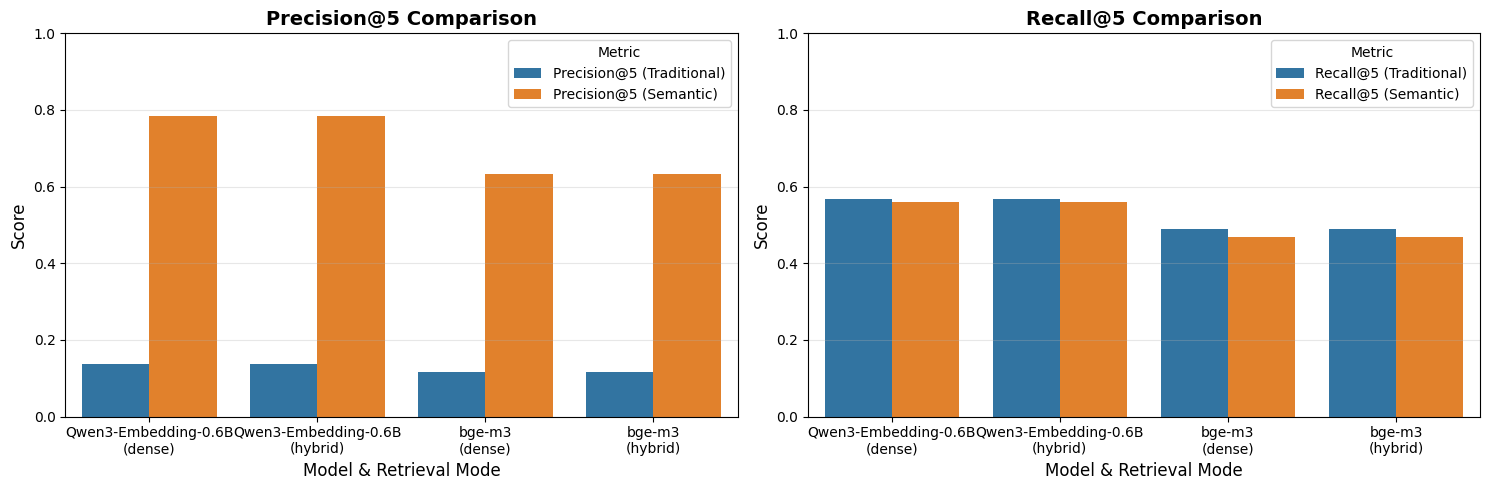

In [11]:
# Cell 5: Plot Precision & Recall
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Precision
df_plot = df[['config', 'precision@5', 'precision@5_semantic']].copy()
df_plot = df_plot.melt(id_vars='config', var_name='metric', value_name='score')
df_plot['metric_label'] = df_plot['metric'].map({
    'precision@5': 'Precision@5 (Traditional)',
    'precision@5_semantic': 'Precision@5 (Semantic)'
})

sns.barplot(data=df_plot, x='config', y='score', hue='metric_label', ax=axes[0])
axes[0].set_title('Precision@5 Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Model & Retrieval Mode', fontsize=12)
axes[0].legend(title='Metric')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Recall
df_plot = df[['config', 'recall@5', 'recall@5_semantic']].copy()
df_plot = df_plot.melt(id_vars='config', var_name='metric', value_name='score')
df_plot['metric_label'] = df_plot['metric'].map({
    'recall@5': 'Recall@5 (Traditional)',
    'recall@5_semantic': 'Recall@5 (Semantic)'
})

sns.barplot(data=df_plot, x='config', y='score', hue='metric_label', ax=axes[1])
axes[1].set_title('Recall@5 Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_xlabel('Model & Retrieval Mode', fontsize=12)
axes[1].legend(title='Metric')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

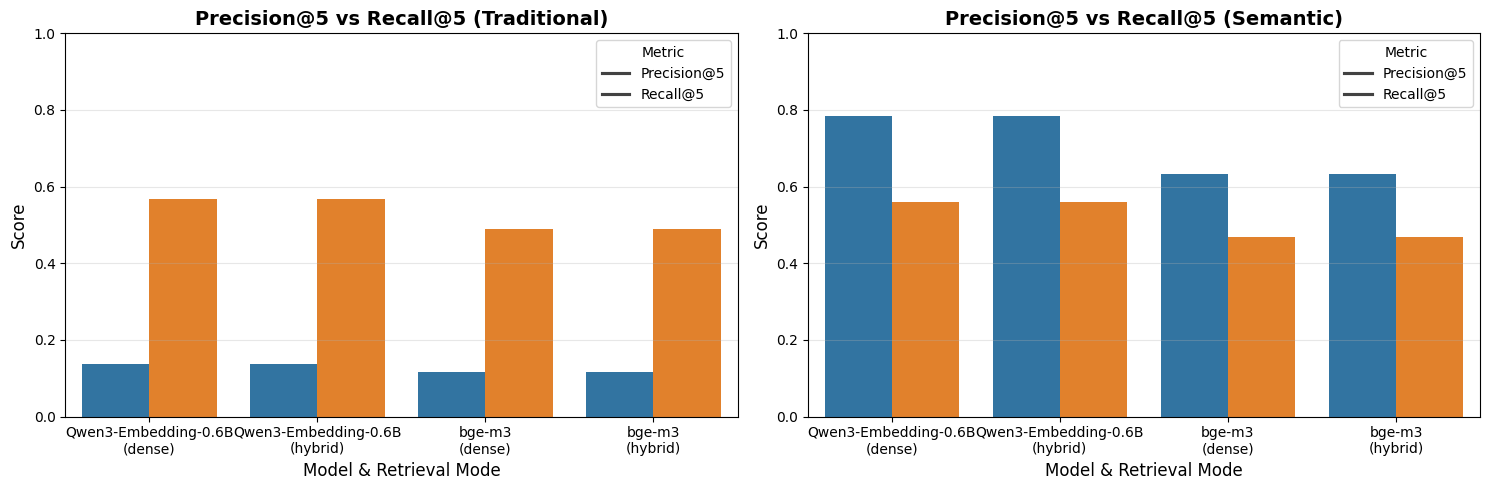

In [12]:
# Cell 5 (Alternative): Precision-Recall Combined
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Traditional Metrics
df_plot = df[['config', 'precision@5', 'recall@5']].copy()
df_plot = df_plot.melt(id_vars='config', var_name='metric', value_name='score')

sns.barplot(data=df_plot, x='config', y='score', hue='metric', ax=axes[0])
axes[0].set_title('Precision@5 vs Recall@5 (Traditional)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Model & Retrieval Mode', fontsize=12)
axes[0].legend(title='Metric', labels=['Precision@5', 'Recall@5'])
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Semantic Metrics
df_plot = df[['config', 'precision@5_semantic', 'recall@5_semantic']].copy()
df_plot = df_plot.melt(id_vars='config', var_name='metric', value_name='score')

sns.barplot(data=df_plot, x='config', y='score', hue='metric', ax=axes[1])
axes[1].set_title('Precision@5 vs Recall@5 (Semantic)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_xlabel('Model & Retrieval Mode', fontsize=12)
axes[1].legend(title='Metric', labels=['Precision@5', 'Recall@5'])
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()